<a href="https://colab.research.google.com/github/sj-workbench/years_of_learnings/blob/main/powertransformer_boxcox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [5]:
df = pd.read_csv("/content/concrete_data.csv")
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [6]:
df.shape

(1030, 9)

In [7]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [8]:
df.describe()  # to check 0 or (-ve), as Box-Cox is not applicablle to zero or negative

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [19]:
x= df.drop(columns = ['Strength'],axis =1)
y= df.iloc[:,-1]

In [20]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state= 42)

In [21]:
print(x_train.shape)
print(x_test.shape)

(824, 8)
(206, 8)


In [22]:
# Applying LR without transformation
lr=LinearRegression()

lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

r2_score(y_test,y_pred)


0.627553179231485

In [23]:
# cross validation
lr = LinearRegression()
np.mean(cross_val_score(lr, x_train, y_train, cv=10, scoring = 'r2'))

np.float64(0.5894185601991604)

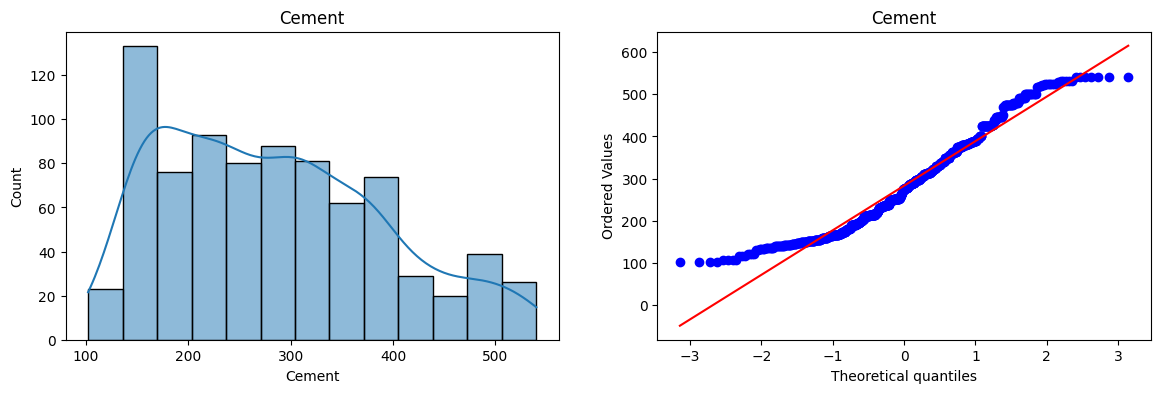

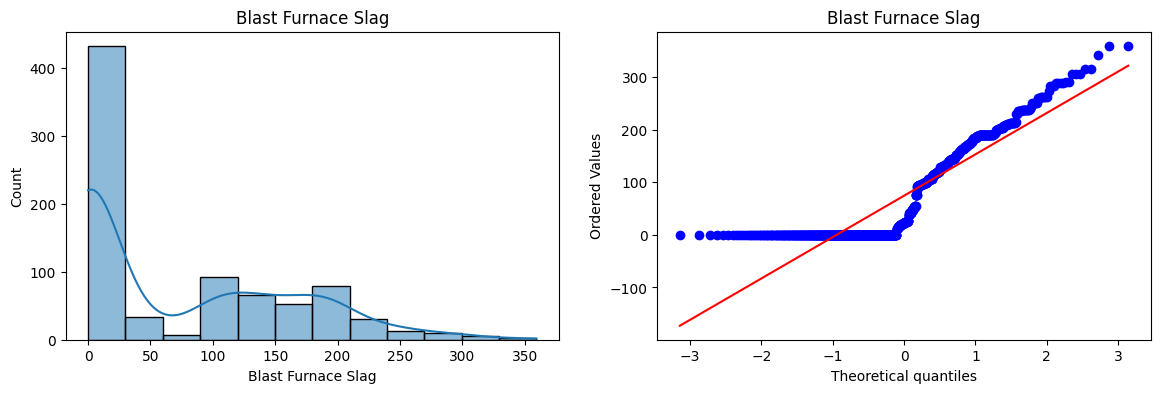

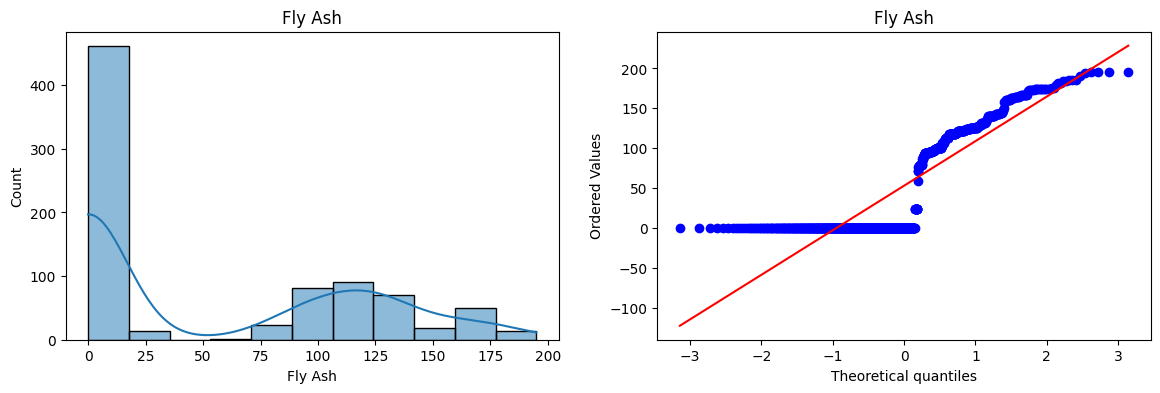

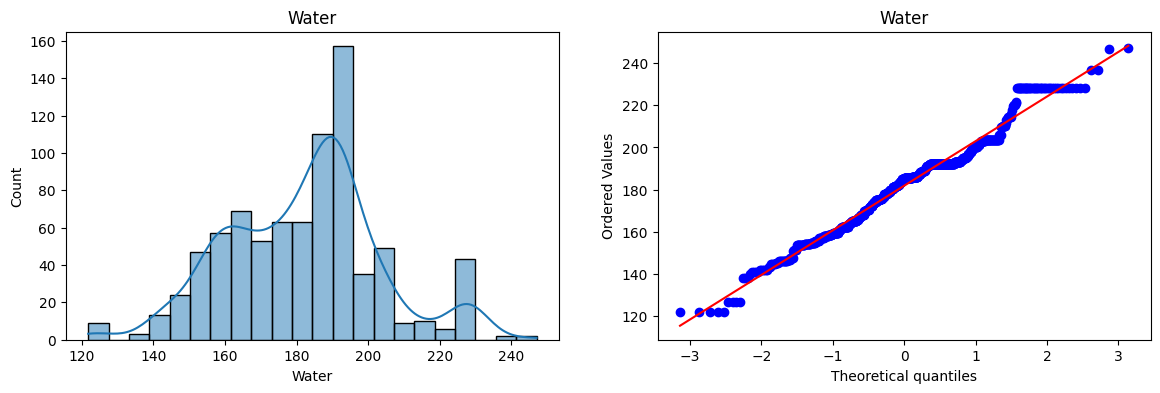

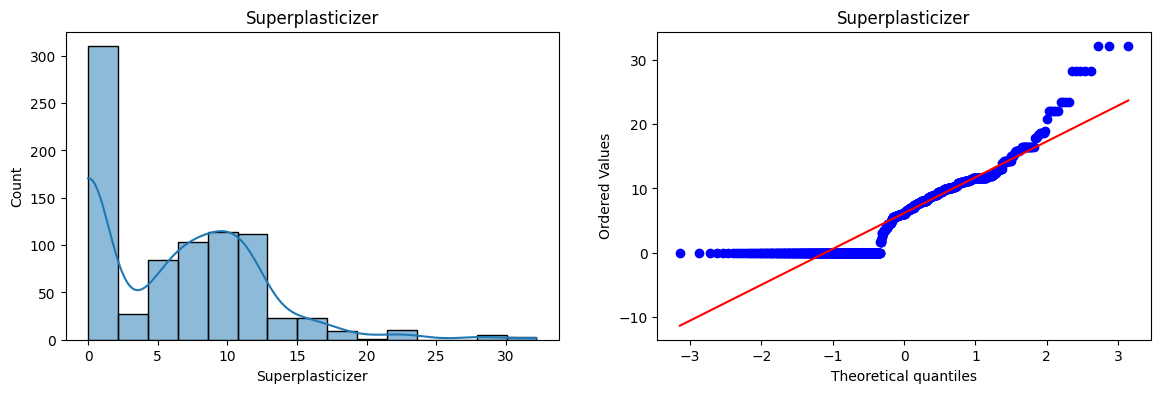

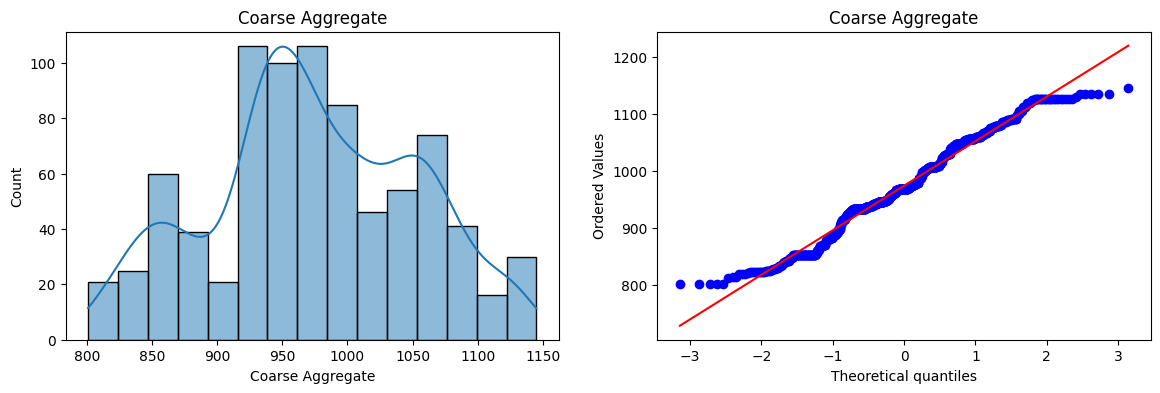

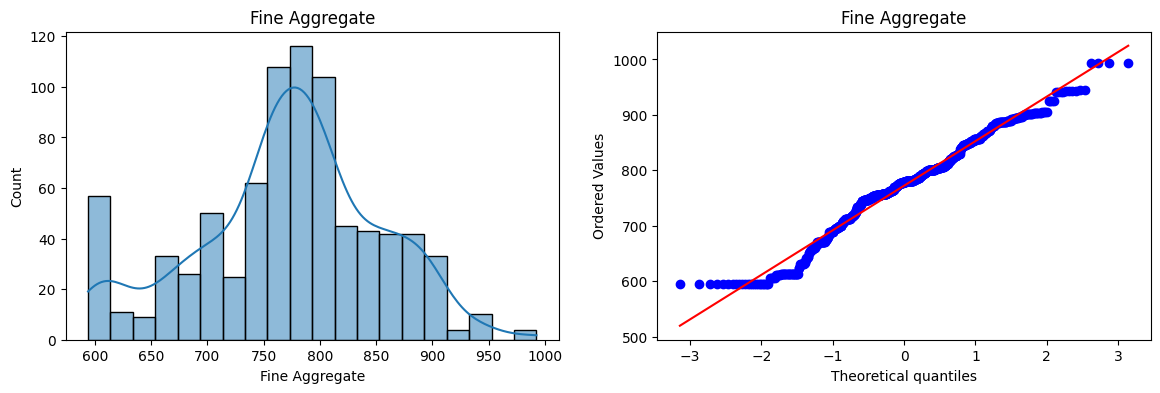

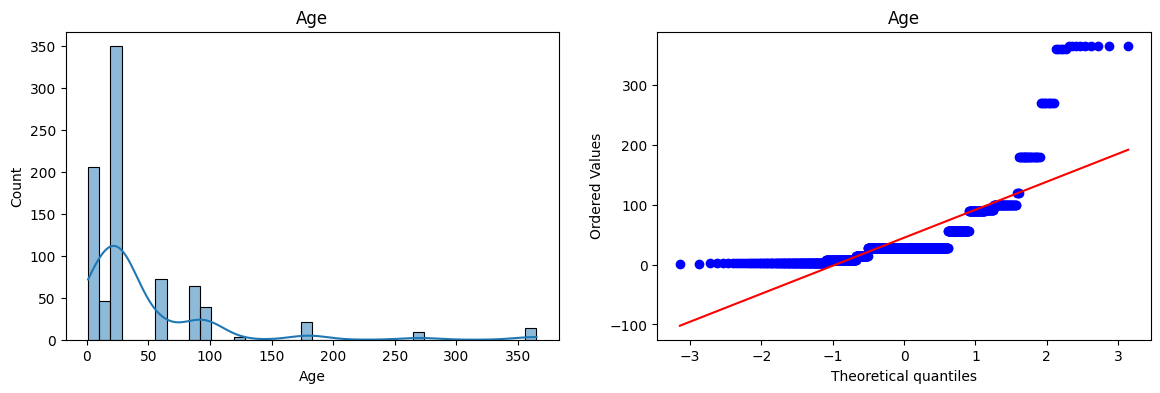

In [24]:
# plotting without any transformation

for col in x_train.columns:
  plt.figure(figsize = (14,4))
  plt.subplot(121)
  sns.histplot(x_train[col],kde = True)
  plt.title(col)

  plt.subplot(122)
  stats.probplot(x_train[col], dist = 'norm', plot = plt)
  plt.title(col)
  plt.show()

In [25]:
# applying box-cox transformation
pt = PowerTransformer(method = 'box-cox')
x_train_boxcox = pt.fit_transform(x_train + 0.000001)
x_test_boxcox = pt.transform(x_test + 0.000001)
pd.DataFrame({'cols': x_train.columns, 'box_cox_lambdas': pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [26]:
# applying LR on transformed
lr = LinearRegression()
lr.fit(x_train_boxcox,y_train)
y_pred = lr.predict(x_test_boxcox)

r2_score(y_test,y_pred)

0.8047824993083206

In [27]:
# using cross val
pt = PowerTransformer(method = 'box-cox')
x_transformed = pt.fit_transform(x+0.000001)

lr = LinearRegression()
np.mean(cross_val_score(lr, x_transformed, y, cv=10, scoring = 'r2'))

np.float64(0.6466764733926945)